In [1]:
import os
import re
from typing import List, Tuple

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold
from gensim.models import Word2Vec
from nltk.corpus import stopwords

from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk

In [2]:
# Download NLTK data
nltk.data.path.append('data/nltk_data')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# <div style="font-family: 'Garamond', serif; font-size: 22px; color: #ffffff; background-color: #34568B; text-align: center; padding: 15px; border-radius: 10px; border: 2px solid #FF6F61; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.3); margin-bottom: 20px;">Step 1: Load the data</div>

## <div style="font-family: 'Lucida Sans Unicode', sans-serif; font-size: 18px; color: #4A235A; background-color: #D7BDE2; text-align: left; padding: 10px; border-left: 5px solid #7D3C98; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.2); margin-bottom: 10px;">Dataset Metadata</div>

### Overview

The dataset contains reviews of fine foods from Amazon, including product and user information, ratings, helpfulness scores, and review text. Each row represents a single review.

---

### Data Dictionary

| Variable               | Definition                                                                 | Key                      |
|------------------------|----------------------------------------------------------------------------|--------------------------|
| Id                     | Review ID                                                                  | Integer                  |
| ProductId              | Unique identifier for the product                                          | Text                     |
| UserId                 | Unique identifier for the user                                             | Text                     |
| ProfileName            | Profile name of the user                                                   | Text                     |
| HelpfulnessNumerator   | Number of users who found the review helpful                               | Integer                  |
| HelpfulnessDenominator | Number of users who indicated whether they found the review helpful or not | Integer                  |
| Score                  | Rating between 1 and 5 given by the user                                   | Integer (1-5)            |
| Time                   | Timestamp for the review                                                   | Integer (Unix timestamp) |
| Summary                | Brief summary of the review                                                | Text                     |
| Text                   | Full text of the review                                                    | Text                     |

---

### Variable Notes

- **Id**: A unique identifier for each review.

- **ProductId**: The Amazon Standard Identification Number (ASIN) for the product.

- **UserId**: A unique identifier for the user who wrote the review.

- **ProfileName**: The display name of the user on Amazon.

- **HelpfulnessNumerator** and **HelpfulnessDenominator**: These indicate how many people found the review helpful. For example, a value of 3/5 means 3 out of 5 people found it helpful.

- **Score**: The star rating given by the reviewer, ranging from 1 (worst) to 5 (best).

- **Time**: The time the review was written, represented as a Unix timestamp.

- **Summary** and **Text**: The summary and the full body of the review, respectively. These contain the textual content of the review.

## <div style="font-family: 'Lucida Sans Unicode', sans-serif; font-size: 18px; color: #4A235A; background-color: #D7BDE2; text-align: left; padding: 10px; border-left: 5px solid #7D3C98; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.2); margin-bottom: 10px;">Load the data and display head</div>

In [3]:
# Check environment if in Kaggle
extract_folder_path = '/kaggle/input/amazon-fine-food-reviews' if os.path.exists('/kaggle/input/amazon-fine-food-reviews') else './data'

# Load the review data
review_file_path = os.path.join(extract_folder_path, 'Reviews.csv')
review_data = pd.read_csv(review_file_path)

# Displaying the first few rows of the dataset
review_data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## <div style="font-family: 'Lucida Sans Unicode', sans-serif; font-size: 18px; color: #4A235A; background-color: #D7BDE2; text-align: left; padding: 10px; border-left: 5px solid #7D3C98; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.2); margin-bottom: 10px;">See the statistical summary of the dataset</div>

In [4]:
# Statistical summary of the dataset
review_data.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


# <div style="font-family: 'Garamond', serif; font-size: 22px; color: #ffffff; background-color: #34568B; text-align: center; padding: 15px; border-radius: 10px; border: 2px solid #FF6F61; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.3); margin-bottom: 20px;">Step 1: Data Preprocessing</div>

## <div style="font-family: 'Lucida Sans Unicode', sans-serif; font-size: 18px; color: #4A235A; background-color: #D7BDE2; text-align: left; padding: 10px; border-left: 5px solid #7D3C98; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.2); margin-bottom: 10px;">Clean the text data</div>

In [5]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess the dataset for sentiment analysis.
    
    - Take the first 10,000 rows
    - Keep only 'Text' and 'Score' columns
    - Convert 'Score' to binary labels: 1 if Score >= 4, else 0
    - Clean the 'Text' column: lowercase, remove punctuation, tokenize, remove stopwords, lemmatize
    - Return DataFrame with 'Cleaned_Text', 'Tokens', and 'Label'

    Args:
        df: Original DataFrame with reviews
    Returns:
        Preprocessed DataFrame
    """
    # Take first 10,000 rows and select columns
    df = df.head(10000)[['Text', 'Score']].copy()
    
    # Convert Score to binary labels
    df['Label'] = (df['Score'] >= 4).astype(int)
    
    # Prepare stopwords and lemmatizer
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    
    def clean_text(text: str) -> Tuple[str, List[str]]:
        """
        Clean and tokenize text.
        Args:
            text: Original text string
        Returns:
            cleaned_text: Cleaned text string
            tokens: List of tokens
        """
        # Lowercase
        text = text.lower()
        # Remove punctuation
        text = re.sub(r'[^\w\s]', '', text)
        # Tokenize
        tokens = word_tokenize(text)
        # Remove stopwords and lemmatize
        tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and word.isalpha()]
        # Join back for TF-IDF
        cleaned_text = ' '.join(tokens)
        return cleaned_text, tokens
    
    # Apply cleaning
    df[['Cleaned_Text', 'Tokens']] = df['Text'].apply(lambda x: pd.Series(clean_text(x)))
    
    return df[['Cleaned_Text', 'Tokens', 'Label']]

# Apply preprocessing
cleaned_df = preprocess(review_data)
cleaned_df.head()

,Cleaned_Text,Tokens,Label
0,bought several vitality canned dog food produc...,"[bought, several, vitality, canned, dog, food,...",1
1,product arrived labeled jumbo salted peanutsth...,"[product, arrived, labeled, jumbo, salted, pea...",0
2,confection around century light pillowy citrus...,"[confection, around, century, light, pillowy, ...",1
3,looking secret ingredient robitussin believe f...,"[looking, secret, ingredient, robitussin, beli...",0
4,great taffy great price wide assortment yummy ...,"[great, taffy, great, price, wide, assortment,...",1


# <div style="font-family: 'Garamond', serif; font-size: 22px; color: #ffffff; background-color: #34568B; text-align: center; padding: 15px; border-radius: 10px; border: 2px solid #FF6F61; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.3); margin-bottom: 20px;">Step 2: Feature Extraction</div>

## <div style="font-family: 'Lucida Sans Unicode', sans-serif; font-size: 18px; color: #4A235A; background-color: #D7BDE2; text-align: left; padding: 10px; border-left: 5px solid #7D3C98; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.2); margin-bottom: 10px;">Extract features using TF-IDF and Word2Vec</div>

In [6]:
def vectorize_tfidf(texts: List[str]) -> np.ndarray:
    """
    Vectorize texts using TF-IDF.
    
    Args:
        texts: List of cleaned text strings
    
    Returns:
        Sparse matrix of TF-IDF features
    """
    vectorizer = TfidfVectorizer(max_features=5000)  # Limit features for efficiency
    return vectorizer.fit_transform(texts)

def vectorize_w2v(tokens_list: List[List[str]], vector_size=100) -> Tuple[np.ndarray, Word2Vec]:
    """
    Train Word2Vec and vectorize documents by averaging word vectors.
    
    Args:
        tokens_list: List of tokenized texts
        vector_size: Dimension of word vectors
    
    Returns:
        Numpy array of document vectors, trained Word2Vec model
    """
    # Train Word2Vec model
    model = Word2Vec(sentences=tokens_list, vector_size=vector_size, window=5, min_count=1, workers=4)
    
    def get_doc_vector(tokens: List[str]) -> np.ndarray:
        """
        Get the average Word2Vec vector for a document.
        Args:
            tokens: List of tokens in the document
        Returns:
            Averaged vector
        """
        vectors = [model.wv[word] for word in tokens if word in model.wv]
        if vectors:
            return np.mean(vectors, axis=0)
        else:
            return np.zeros(vector_size)
    
    # Get document vectors
    document_vectors = np.array([get_doc_vector(tokens) for tokens in tokens_list])
    return document_vectors, model

# Extract features
feature_matrix_tfidf = vectorize_tfidf(cleaned_df['Cleaned_Text'])
feature_matrix_w2v, w2v_model = vectorize_w2v(cleaned_df['Tokens'])

# Labels
y = cleaned_df['Label']

print(f"TF-IDF shape: {feature_matrix_tfidf.shape}")
print(f"Word2Vec shape: {feature_matrix_w2v.shape}")
print(f"Labels shape: {y.shape}")

TF-IDF shape: (10000, 5000)
Word2Vec shape: (10000, 100)
Labels shape: (10000,)


# <div style="font-family: 'Garamond', serif; font-size: 22px; color: #ffffff; background-color: #34568B; text-align: center; padding: 15px; border-radius: 10px; border: 2px solid #FF6F61; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.3); margin-bottom: 20px;">Step 3: Model Training</div>

## <div style="font-family: 'Lucida Sans Unicode', sans-serif; font-size: 18px; color: #4A235A; background-color: #D7BDE2; text-align: left; padding: 10px; border-left: 5px solid #7D3C98; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.2); margin-bottom: 10px;">Train RandomForestClassifier on both feature sets</div>

In [7]:
def train_model(feature_matrix: np.ndarray, labels: pd.Series) -> RandomForestClassifier:
    """
    Train a RandomForestClassifier on the given features and labels.
    
    Args:
        feature_matrix: Feature matrix
        labels: Labels
    
    Returns:
        Trained model
    """
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(feature_matrix, labels)
    return model

# Train models
model_tfidf = train_model(feature_matrix_tfidf, y)
model_w2v = train_model(feature_matrix_w2v, y)

print("Models trained successfully.")

Models trained successfully.


# <div style="font-family: 'Garamond', serif; font-size: 22px; color: #ffffff; background-color: #34568B; text-align: center; padding: 15px; border-radius: 10px; border: 2px solid #FF6F61; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.3); margin-bottom: 20px;">Step 4: Model Evaluation</div>

## <div style="font-family: 'Lucida Sans Unicode', sans-serif; font-size: 18px; color: #4A235A; background-color: #D7BDE2; text-align: left; padding: 10px; border-left: 5px solid #7D3C98; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.2); margin-bottom: 10px;">Evaluate models using 4-fold cross-validation and compare results</div>

In [8]:
def evaluate_model(model: RandomForestClassifier, feature_matrix: np.ndarray, labels: pd.Series, cv=4) -> (float, float):
    """
    Evaluate model using 4-fold cross-validation.
    
    Args:
        model: Trained model
        feature_matrix: Feature matrix
        labels: Labels
        cv: Number of folds
    
    Returns:
        Mean accuracy and standard deviation
    """
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    accuracy_scores = cross_val_score(model, feature_matrix, labels, cv=kf, scoring='accuracy')
    return accuracy_scores.mean(), accuracy_scores.std()

# Evaluate models
mean_acc_tfidf, std_acc_tfidf = evaluate_model(model_tfidf, feature_matrix_tfidf, y)
mean_acc_w2v, std_acc_w2v = evaluate_model(model_w2v, feature_matrix_w2v, y)

# Print results
print(f"TF-IDF: Mean Accuracy = {mean_acc_tfidf:.4f}, Std Dev = {std_acc_tfidf:.4f}")
print(f"Word2Vec: Mean Accuracy = {mean_acc_w2v:.4f}, Std Dev = {std_acc_w2v:.4f}")

# Create comparison table
import pandas as pd
results_df = pd.DataFrame({
    'Model': ['TF-IDF', 'Word2Vec'],
    'Mean Accuracy': [mean_acc_tfidf, mean_acc_w2v],
    'Std Dev': [std_acc_tfidf, std_acc_w2v]
})
results_df

TF-IDF: Mean Accuracy = 0.8311, Std Dev = 0.0054
Word2Vec: Mean Accuracy = 0.7982, Std Dev = 0.0058


,Model,Mean Accuracy,Std Dev
0,TF-IDF,0.8311,0.005377
1,Word2Vec,0.7982,0.005752


# <div style="font-family: 'Garamond', serif; font-size: 22px; color: #ffffff; background-color: #34568B; text-align: center; padding: 15px; border-radius: 10px; border: 2px solid #FF6F61; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.3); margin-bottom: 20px;">Step 5: Visualization and Report</div>

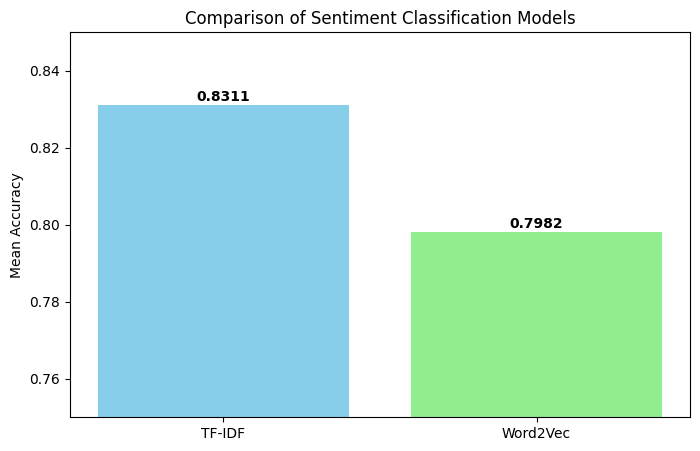

In [9]:
# Bar chart comparing accuracies
models = results_df['Model']
accuracies = results_df['Mean Accuracy']

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['skyblue', 'lightgreen'])
plt.ylabel('Mean Accuracy')
plt.title('Comparison of Sentiment Classification Models')
plt.ylim(0.75, 0.85)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

# <div style="font-family: 'Garamond', serif; font-size: 22px; color: #ffffff; background-color: #34568B; text-align: center; padding: 15px; border-radius: 10px; border: 2px solid #FF6F61; box-shadow: 0 6px 12px rgba(0, 0, 0, 0.3); margin-bottom: 20px;">Step 6: Create Test Submission</div>

## <div style="font-family: 'Lucida Sans Unicode', sans-serif; font-size: 18px; color: #4A235A; background-color: #D7BDE2; text-align: left; padding: 10px; border-left: 5px solid #7D3C98; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.2); margin-bottom: 10px;">Load and preprocess the test data</div>

In [10]:
# Load test data
extract_folder_path = '/kaggle/input/hw2-sentiment-analysis' if os.path.exists('/kaggle/input/hw2-sentiment-analysis') else './data'
test_file_path = os.path.join(extract_folder_path, 'test.csv')
test_data = pd.read_csv(test_file_path)
print(f"Test data shape: {test_data.shape}")
test_data.head()

# Preprocess test data (only clean text, no labels)
def preprocess_test(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess the test dataset.

    Args:
        df: Original test DataFrame with reviews
    Returns:
        Preprocessed DataFrame with 'Cleaned_Text'
    """
    df = df.copy()
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    
    def clean_text(text: str) -> Tuple[str, List[str]]:
        """
        Clean and tokenize text.
        Args:
            text: Original text string
        Returns:
            cleaned_text: Cleaned text string
            tokens: List of tokens
        """
        # Lowercase
        text = text.lower()
        # Remove punctuation
        text = re.sub(r'[^\w\s]', '', text)
        # Tokenize
        tokens = word_tokenize(text)
        # Remove stopwords and lemmatize
        tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and word.isalpha()]
        # Join back for TF-IDF
        cleaned_text = ' '.join(tokens)
        return cleaned_text, tokens
    
    # Apply cleaning
    df[['Cleaned_Text', 'Tokens']] = df['Text'].apply(lambda x: pd.Series(clean_text(x)))
    return df

test_cleaned = preprocess_test(test_data)

Test data shape: (5000, 1)


## <div style="font-family: 'Lucida Sans Unicode', sans-serif; font-size: 18px; color: #4A235A; background-color: #D7BDE2; text-align: left; padding: 10px; border-left: 5px solid #7D3C98; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.2); margin-bottom: 10px;">Vectorize test data and make predictions using TF-IDF</div>

In [11]:
# Vectorize test data using the same TF-IDF vectorizer
# We need to fit on training data, but since we used fit_transform, we need to refit or use the same vectorizer
# For simplicity, refit on training cleaned text
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_vectorizer.fit(cleaned_df['Cleaned_Text'])
feature_matrix_test_tfidf = tfidf_vectorizer.transform(test_cleaned['Cleaned_Text'])

# Predict using the better model (TF-IDF)
predictions = model_tfidf.predict(feature_matrix_test_tfidf)

## <div style="font-family: 'Lucida Sans Unicode', sans-serif; font-size: 18px; color: #4A235A; background-color: #D7BDE2; text-align: left; padding: 10px; border-left: 5px solid #7D3C98; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.2); margin-bottom: 10px;">Create TF-IDF submission file</div>

In [12]:
# Create submission DataFrame (1-based index)
submission = pd.DataFrame({
    'ID': np.arange(1, len(predictions) + 1),
    'Score': predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("Submission file created: submission.csv")
submission.head()

Submission file created: submission.csv


,ID,Score
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1


## <div style="font-family: 'Lucida Sans Unicode', sans-serif; font-size: 18px; color: #4A235A; background-color: #D7BDE2; text-align: left; padding: 10px; border-left: 5px solid #7D3C98; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.2); margin-bottom: 10px;">Vectorize test data and make predictions using Word2Vec</div>

In [13]:
# Vectorize test data using Word2Vec
def vectorize_test_w2v(tokens_list: List[List[str]], model: Word2Vec) -> np.ndarray:
    """
    Vectorize test documents using a pre-trained Word2Vec model.
    
    Args:
        tokens_list: List of tokenized texts
        model: Trained Word2Vec model
    
    Returns:
        Numpy array of document vectors
    """
    def get_doc_vector(tokens: List[str]) -> np.ndarray:
        """
        Get the average Word2Vec vector for a document.
        Args:
            tokens: List of tokens in the document
        Returns:
            Averaged vector
        """
        vectors = [model.wv[word] for word in tokens if word in model.wv]
        if vectors:
            return np.mean(vectors, axis=0)
        else:
            return np.zeros(model.vector_size)
    
    return np.array([get_doc_vector(tokens) for tokens in tokens_list])

feature_matrix_test_w2v = vectorize_test_w2v(test_cleaned['Tokens'], w2v_model)

# Predict using Word2Vec model
predictions_w2v = model_w2v.predict(feature_matrix_test_w2v)

## <div style="font-family: 'Lucida Sans Unicode', sans-serif; font-size: 18px; color: #4A235A; background-color: #D7BDE2; text-align: left; padding: 10px; border-left: 5px solid #7D3C98; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.2); margin-bottom: 10px;">Create Word2Vec submission file</div>

In [14]:
# Create Word2Vec submission DataFrame (1-based index)
submission_w2v = pd.DataFrame({
    'ID': np.arange(1, len(predictions_w2v) + 1),
    'Score': predictions_w2v
})

# Save to CSV
submission_w2v.to_csv('submission_w2v.csv', index=False)
print("Word2Vec submission file created: submission_w2v.csv")

# Simple comparison: number of positive predictions
print(f"TF-IDF positive predictions: {sum(predictions)}")
print(f"Word2Vec positive predictions: {sum(predictions_w2v)}")

submission_w2v.head()

Word2Vec submission file created: submission_w2v.csv
TF-IDF positive predictions: 4566
Word2Vec positive predictions: 4611


,ID,Score
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1
